# Import the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

import warnings
warnings.filterwarnings("ignore")

In [2]:
movies = pd.read_excel(r"D:\BOSTON\New folder\ml-latest-small\movies_dataset.xlsx")
ratings = pd.read_excel(r"D:\BOSTON\New folder\ml-latest-small\ratings_dataset.xlsx")
users = pd.read_excel(r"D:\BOSTON\New folder\ml-latest-small\user_dataset.xlsx")

In [3]:
movies.head()

,movieId,title,genres,actor,director,language,release_year,tags
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"Natalie Portman, Robert Downey Jr., Leonardo D...",Martin Scorsese,English,1995,"adventure, animation, children, comedy, fantasy"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"Natalie Portman, Morgan Freeman, Jennifer Lawr...",Christopher Nolan,English,1995,"adventure, children, fantasy"
2,3,Grumpier Old Men (1995),Comedy|Romance,"Emma Stone, Keanu Reeves, Robert Downey Jr.",Quentin Tarantino,English,1995,"comedy, romance"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"Emma Stone, Tom Hanks, Jennifer Lawrence",Steven Spielberg,English,1995,"comedy, drama, romance"
4,5,Father of the Bride Part II (1995),Comedy,"Jennifer Lawrence, Brad Pitt, Morgan Freeman",Peter Jackson,English,1995,comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
users.head()

,userId,user_name,favorite_actor,favorite_director,age,gender,occupation,city,country,preferred_genre,subscription_type,preferred_language,average_watch_time_min,device,weekly_movies_watched,average_rating_given,member_since
0,1,Abhishek Jain,Al Pacino,Martin Scorsese,29,Other,Software Engineer,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25
1,2,Riya Jain,Morgan Freeman,Ridley Scott,52,Male,Business Analyst,Chennai,India,Children,Standard,English,120,Tablet,1,4.4,2021-06-20
2,3,Akash Malhotra,Keanu Reeves,Steven Spielberg,18,Male,Manager,Pune,India,(no genres listed),Basic,Tamil,100,Mobile,10,5.0,2021-12-10
3,4,Karan Kulkarni,Scarlett Johansson,John Lasseter,40,Male,Software Engineer,Jaipur,India,Animation,Basic,English,60,Smart TV,3,3.8,2023-04-15
4,5,Varun Rao,Scarlett Johansson,Christopher Nolan,47,Male,Entrepreneur,Mumbai,India,Film-Noir,Premium,English,60,Laptop,5,4.3,2018-08-26


# data understanding

In [6]:
print("Users Shape :", users.shape)
print("Movies Shape :", movies.shape)
print("Ratings Shape :", ratings.shape)

Users Shape : (1000, 17)
Movies Shape : (9742, 8)
Ratings Shape : (100836, 4)


# Display Datatypes

In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   movieId       9742 non-null   int64 
 1   title         9742 non-null   object
 2   genres        9742 non-null   object
 3   actor         9742 non-null   object
 4   director      9742 non-null   object
 5   language      9742 non-null   object
 6   release_year  9742 non-null   int64 
 7   tags          9742 non-null   object
dtypes: int64(2), object(6)
memory usage: 609.0+ KB


In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   userId                  1000 non-null   int64  
 1   user_name               1000 non-null   object 
 2   favorite_actor          1000 non-null   object 
 3   favorite_director       1000 non-null   object 
 4   age                     1000 non-null   int64  
 5   gender                  1000 non-null   object 
 6   occupation              1000 non-null   object 
 7   city                    1000 non-null   object 
 8   country                 1000 non-null   object 
 9   preferred_genre         1000 non-null   object 
 10  subscription_type       1000 non-null   object 
 11  preferred_language      1000 non-null   object 
 12  average_watch_time_min  1000 non-null   int64  
 13  device                  1000 non-null   object 
 14  weekly_movies_watched   1000 non-null   i

# check missing values

In [10]:
print("Movies")
print(movies.isnull().sum())

print("\nRatings")
print(ratings.isnull().sum())

print("\nUsers")
print(users.isnull().sum())

Movies
movieId         0
title           0
genres          0
actor           0
director        0
language        0
release_year    0
tags            0
dtype: int64

Ratings
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Users
userId                    0
user_name                 0
favorite_actor            0
favorite_director         0
age                       0
gender                    0
occupation                0
city                      0
country                   0
preferred_genre           0
subscription_type         0
preferred_language        0
average_watch_time_min    0
device                    0
weekly_movies_watched     0
average_rating_given      0
member_since              0
dtype: int64


In [11]:
movies = movies.dropna(subset=["movieId"])
movies["movieId"] = movies["movieId"].astype(int)

In [12]:
movies.isnull().sum()

movieId         0
title           0
genres          0
actor           0
director        0
language        0
release_year    0
tags            0
dtype: int64

In [13]:
# Duplicate Values
print("Users Duplicates :", users.duplicated().sum())
print("Movies Duplicates :", movies.duplicated().sum())
print("Ratings Duplicates :", ratings.duplicated().sum())

Users Duplicates : 0
Movies Duplicates : 0
Ratings Duplicates : 0


In [14]:
movies.describe()

,movieId,release_year
count,9742.000000,9742.000000
mean,42200.353623,1994.615685
std,52160.494854,18.530112
min,1.000000,1902.000000
25%,3248.250000,1987.250000
50%,7300.000000,1999.000000
75%,76232.000000,2008.000000
max,193609.000000,2018.000000


In [15]:
ratings.describe()

,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [16]:
users.describe()

,userId,age,average_watch_time_min,weekly_movies_watched,average_rating_given
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,39.436000,111.665000,5.538000,3.708600
std,288.819436,11.999579,39.256768,2.879035,0.729972
min,1.000000,18.000000,60.000000,1.000000,2.500000
25%,250.750000,30.000000,75.000000,3.000000,3.100000
50%,500.500000,39.000000,100.000000,6.000000,3.700000
75%,750.250000,50.000000,150.000000,8.000000,4.300000
max,1000.000000,60.000000,180.000000,10.000000,5.000000


# Check Column Names

In [17]:
print(users.columns.tolist())

print(movies.columns.tolist())

print(ratings.columns.tolist())

['userId', 'user_name', 'favorite_actor', 'favorite_director', 'age', 'gender', 'occupation', 'city', 'country', 'preferred_genre', 'subscription_type', 'preferred_language', 'average_watch_time_min', 'device', 'weekly_movies_watched', 'average_rating_given', 'member_since']
['movieId', 'title', 'genres', 'actor', 'director', 'language', 'release_year', 'tags']
['userId', 'movieId', 'rating', 'timestamp']


In [18]:
# Convert Timestamp
ratings["timestamp"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

# EDA

In [19]:
movie_rating = pd.merge(

    ratings,
    movies,
    on="movieId",
    how="left"
)

movie_data = pd.merge(
    movie_rating,
    users,
    on="userId",
    how="left"
)

movie_data.head()

,userId,movieId,rating,timestamp,title,genres,actor,director,language,release_year,...,city,country,preferred_genre,subscription_type,preferred_language,average_watch_time_min,device,weekly_movies_watched,average_rating_given,member_since
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"Natalie Portman, Robert Downey Jr., Leonardo D...",Martin Scorsese,English,1995,...,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,"Emma Stone, Keanu Reeves, Robert Downey Jr.",Quentin Tarantino,English,1995,...,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,"Emma Stone, Keanu Reeves, Morgan Freeman",Steven Spielberg,English,1995,...,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,"Morgan Freeman, Brad Pitt, Keanu Reeves",Peter Jackson,English,1995,...,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,"Morgan Freeman, Emma Stone, Scarlett Johansson",Christopher Nolan,English,1995,...,Jaipur,India,Sci-Fi,Basic,English,75,Mobile,1,2.9,2018-01-25


In [20]:
print("Movies :", movies.shape)
print("Ratings:", ratings.shape)
print("Users :", users.shape)
print("Merged :", movie_data.shape)

Movies : (9742, 8)
Ratings: (100836, 4)
Users : (1000, 17)
Merged : (100836, 27)


In [21]:
movie_data.isnull().sum()

userId                    0
movieId                   0
rating                    0
timestamp                 0
title                     0
genres                    0
actor                     0
director                  0
language                  0
release_year              0
tags                      0
user_name                 0
favorite_actor            0
favorite_director         0
age                       0
gender                    0
occupation                0
city                      0
country                   0
preferred_genre           0
subscription_type         0
preferred_language        0
average_watch_time_min    0
device                    0
weekly_movies_watched     0
average_rating_given      0
member_since              0
dtype: int64

In [22]:
movie_data.duplicated().sum()

0

In [23]:
movie_data.describe()

,userId,movieId,rating,timestamp,release_year,age,average_watch_time_min,weekly_movies_watched,average_rating_given
count,100836.000000,100836.000000,100836.000000,100836,100836.000000,100836.000000,100836.000000,100836.000000,100836.000000
mean,326.127564,19435.295718,3.501557,2008-03-19 17:01:27.368469248,1994.445486,39.870741,113.249088,5.413682,3.666778
min,1.000000,1.000000,0.500000,1996-03-29 18:36:55,1902.000000,18.000000,60.000000,1.000000,2.500000
25%,177.000000,1199.000000,3.000000,2002-04-18 09:57:46,1990.000000,31.000000,75.000000,3.000000,3.100000
50%,325.000000,2991.000000,3.500000,2007-08-02 20:31:02,1997.000000,40.000000,100.000000,6.000000,3.600000
75%,477.000000,8122.000000,4.000000,2015-07-04 07:15:44.500000,2003.000000,49.000000,150.000000,8.000000,4.300000
max,610.000000,193609.000000,5.000000,2018-09-24 14:27:30,2018.000000,60.000000,180.000000,10.000000,5.000000
std,182.618491,35530.987199,1.042529,NaN,14.361327,11.530444,39.182717,2.774634,0.735154


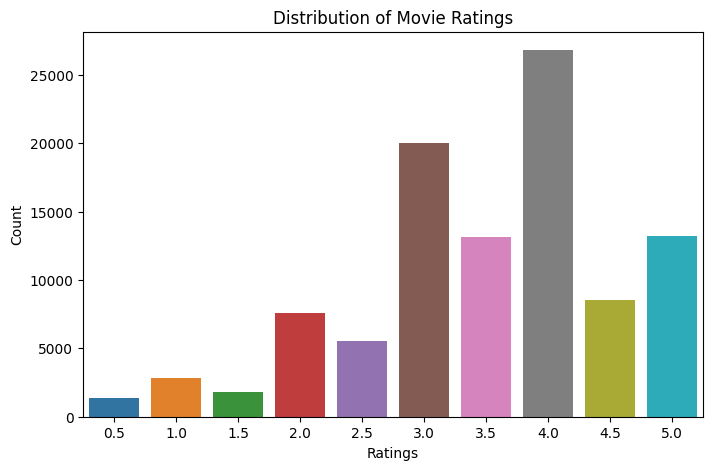

In [24]:
# Distribution Ratings
plt.figure(figsize=(8,5))

sns.countplot(x="rating", data=ratings)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

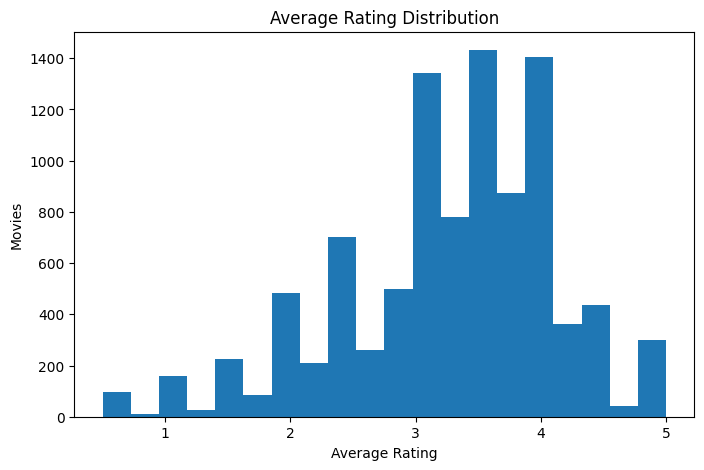

In [25]:
# Average ratings
avg_rating = ratings.groupby("movieId")["rating"].mean()

plt.figure(figsize=(8,5))

plt.hist(avg_rating, bins=20)

plt.title("Average Rating Distribution")

plt.xlabel("Average Rating")

plt.ylabel("Movies")

plt.show()

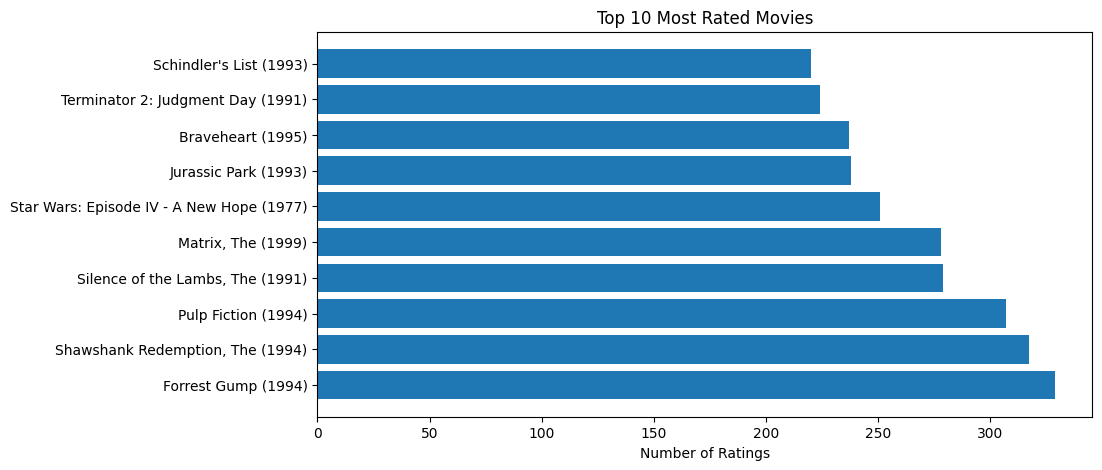

In [26]:
# Most Rated movie
top_movies = ratings.groupby("movieId")["rating"].count()

top_movies = top_movies.sort_values(ascending=False).head(10)

top_movies = top_movies.reset_index()

top_movies = top_movies.merge(
    movies[["movieId","title"]],
    on="movieId"
)

plt.figure(figsize=(10,5))

plt.barh(top_movies["title"],
         top_movies["rating"])

plt.title("Top 10 Most Rated Movies")

plt.xlabel("Number of Ratings")

plt.show()

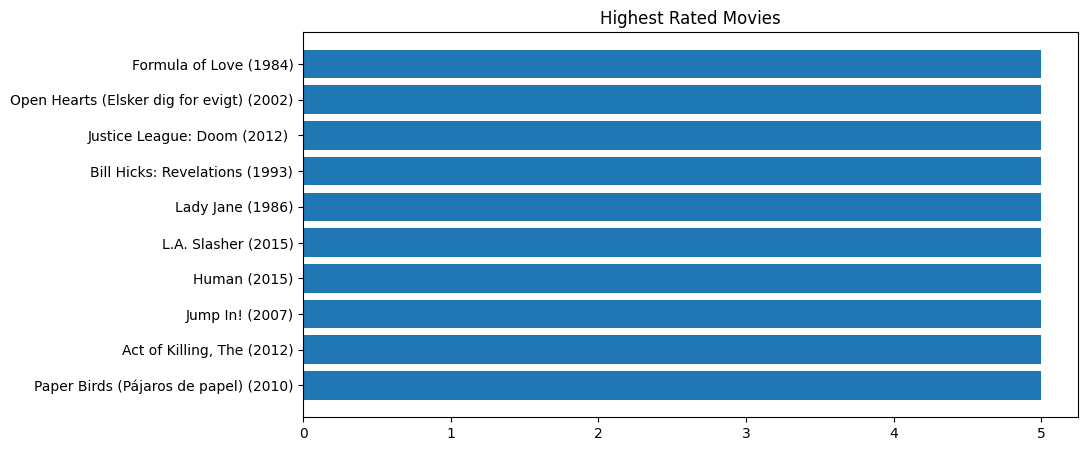

In [27]:
# Highest Rated Movies
highest = ratings.groupby("movieId")["rating"].mean()

highest = highest.sort_values(ascending=False).head(10)

highest = highest.reset_index()

highest = highest.merge(
    movies[["movieId","title"]],
    on="movieId"
)

plt.figure(figsize=(10,5))

plt.barh(highest["title"],
         highest["rating"])

plt.title("Highest Rated Movies")

plt.show()

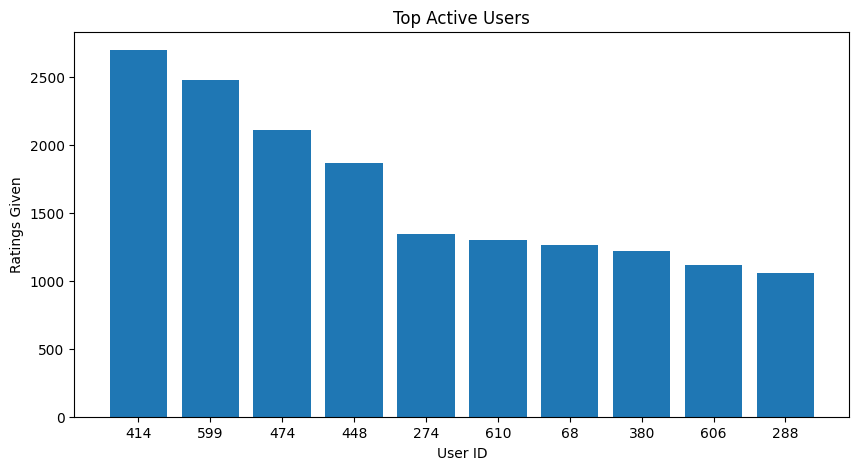

In [28]:
# Top Active Users

top_users = ratings.groupby("userId")["rating"].count()

top_users = top_users.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_users.index.astype(str),
        top_users.values)

plt.title("Top Active Users")

plt.xlabel("User ID")

plt.ylabel("Ratings Given")

plt.show()

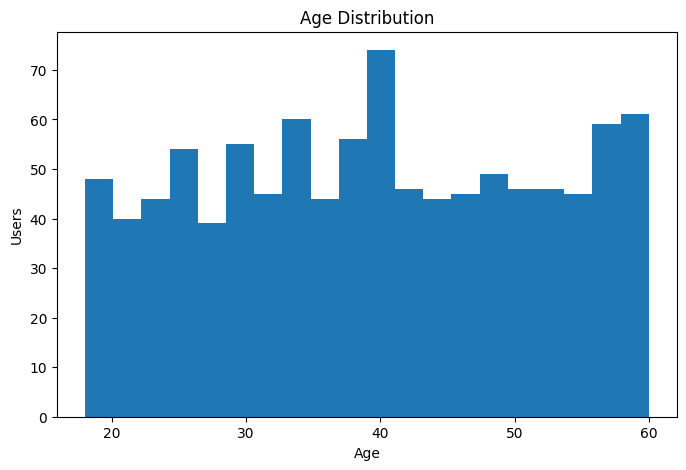

In [29]:
# Age Distribution
plt.figure(figsize=(8,5))

plt.hist(users["age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Users")

plt.show()

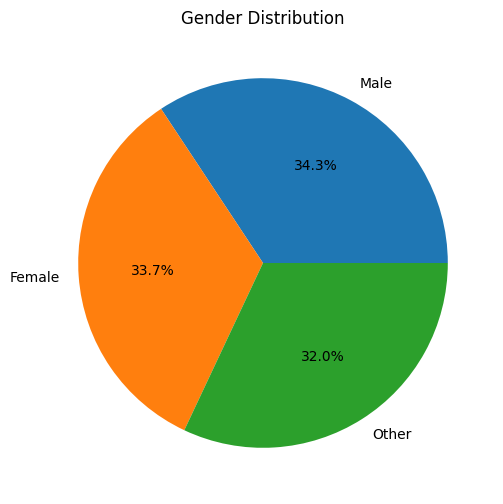

In [30]:
# Gender Distribution
users["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Gender Distribution")

plt.ylabel("")

plt.show()

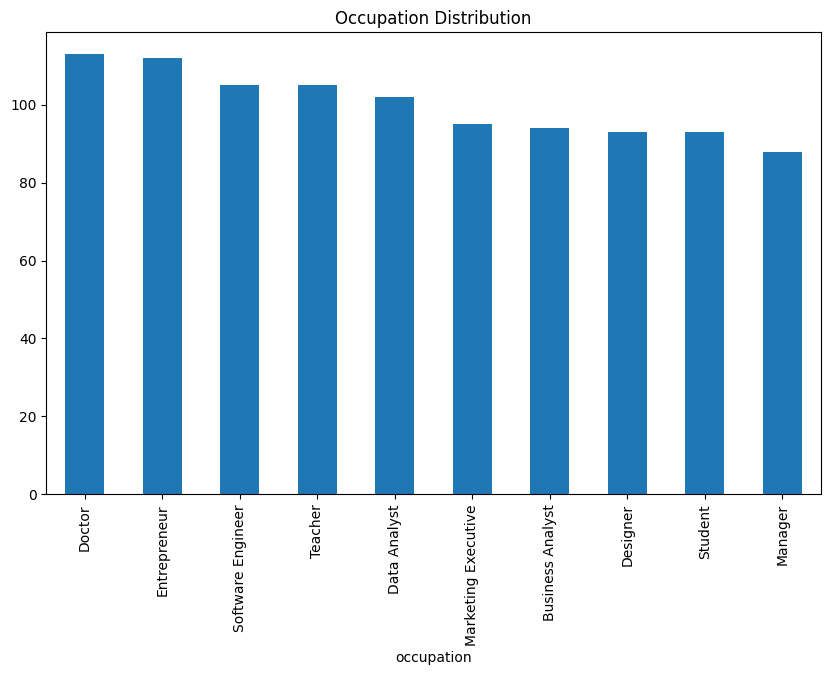

In [31]:
# Occupation Distribution
plt.figure(figsize=(10,6))

users["occupation"].value_counts().plot(kind="bar")

plt.title("Occupation Distribution")

plt.show()

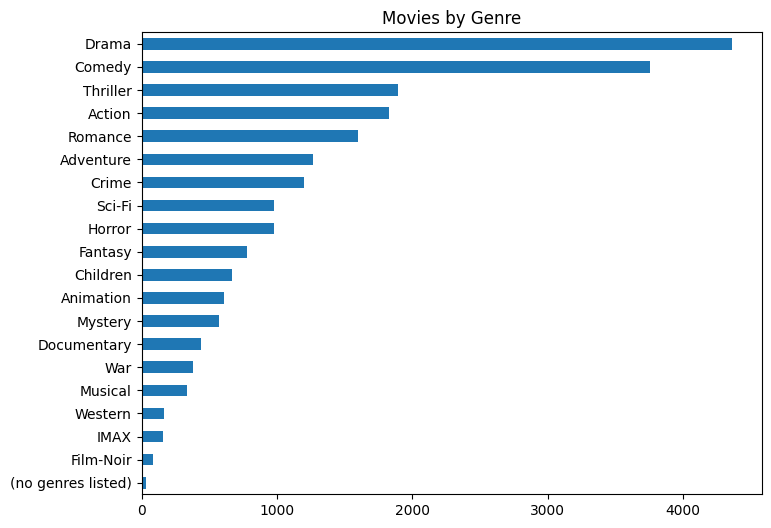

In [32]:
# Movie Genres
genres = movies["genres"].str.get_dummies("|")

genre_count = genres.sum()

genre_count.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Movies by Genre")

plt.show()

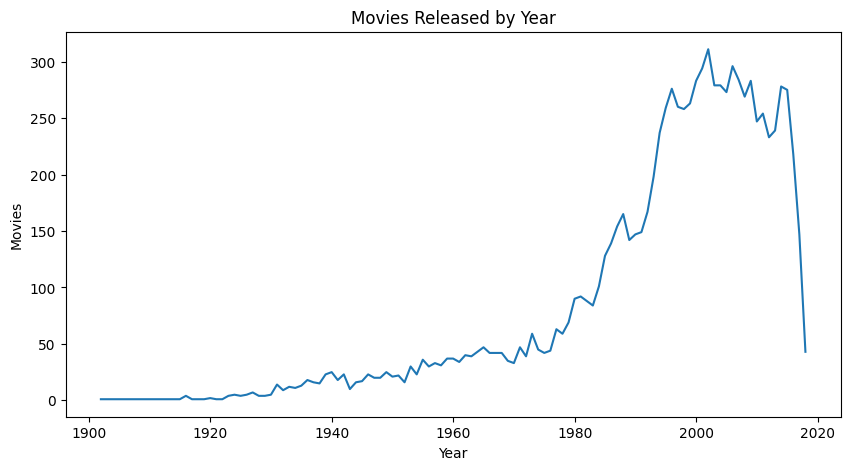

In [33]:
# Movies Released Per Year
plt.figure(figsize=(10,5))

movies["release_year"].value_counts().sort_index().plot()

plt.title("Movies Released by Year")

plt.xlabel("Year")

plt.ylabel("Movies")

plt.show()

In [34]:
# Ratings by Genre
genre_rating = pd.concat(
    [movies["genres"],
     ratings["rating"]],
    axis=1
)

genre_rating.head()

,genres,rating
0,Adventure|Animation|Children|Comedy|Fantasy,4.0
1,Adventure|Children|Fantasy,4.0
2,Comedy|Romance,4.0
3,Comedy|Drama|Romance,5.0
4,Comedy,5.0


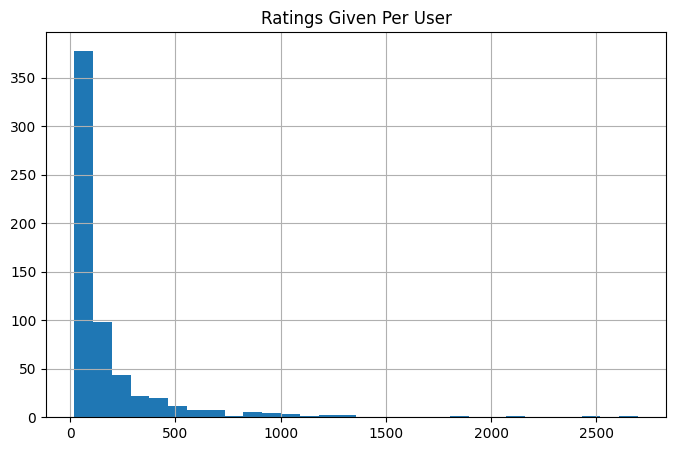

In [35]:
# Ratings Per User
ratings.groupby("userId")["rating"].count().hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Ratings Given Per User")

plt.show()

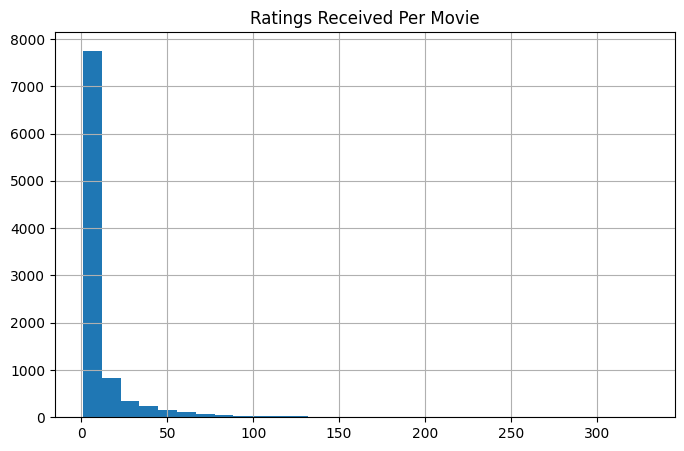

In [36]:
# Ratings Per Movie
ratings.groupby("movieId")["rating"].count().hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Ratings Received Per Movie")

plt.show()

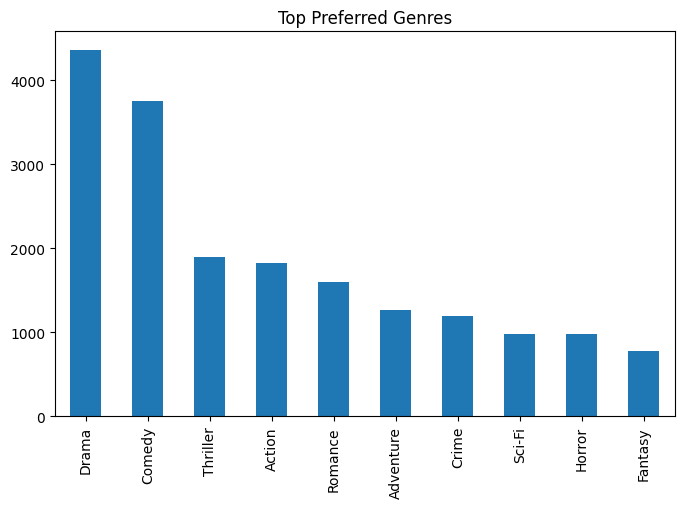

In [37]:
# Top prefered genres
genre_count.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Top Preferred Genres")

plt.show()

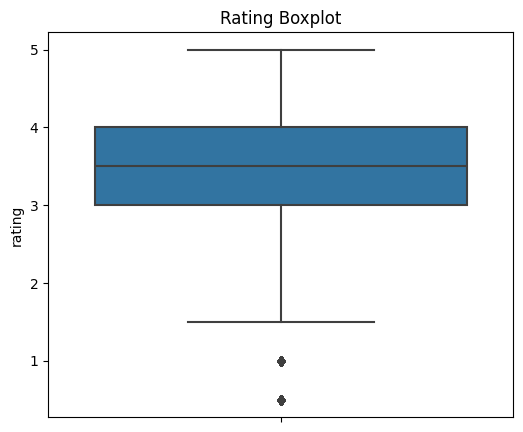

In [38]:
# Rating Boxplot
plt.figure(figsize=(6,5))

sns.boxplot(
    y=ratings["rating"]
)

plt.title("Rating Boxplot")
plt.show()

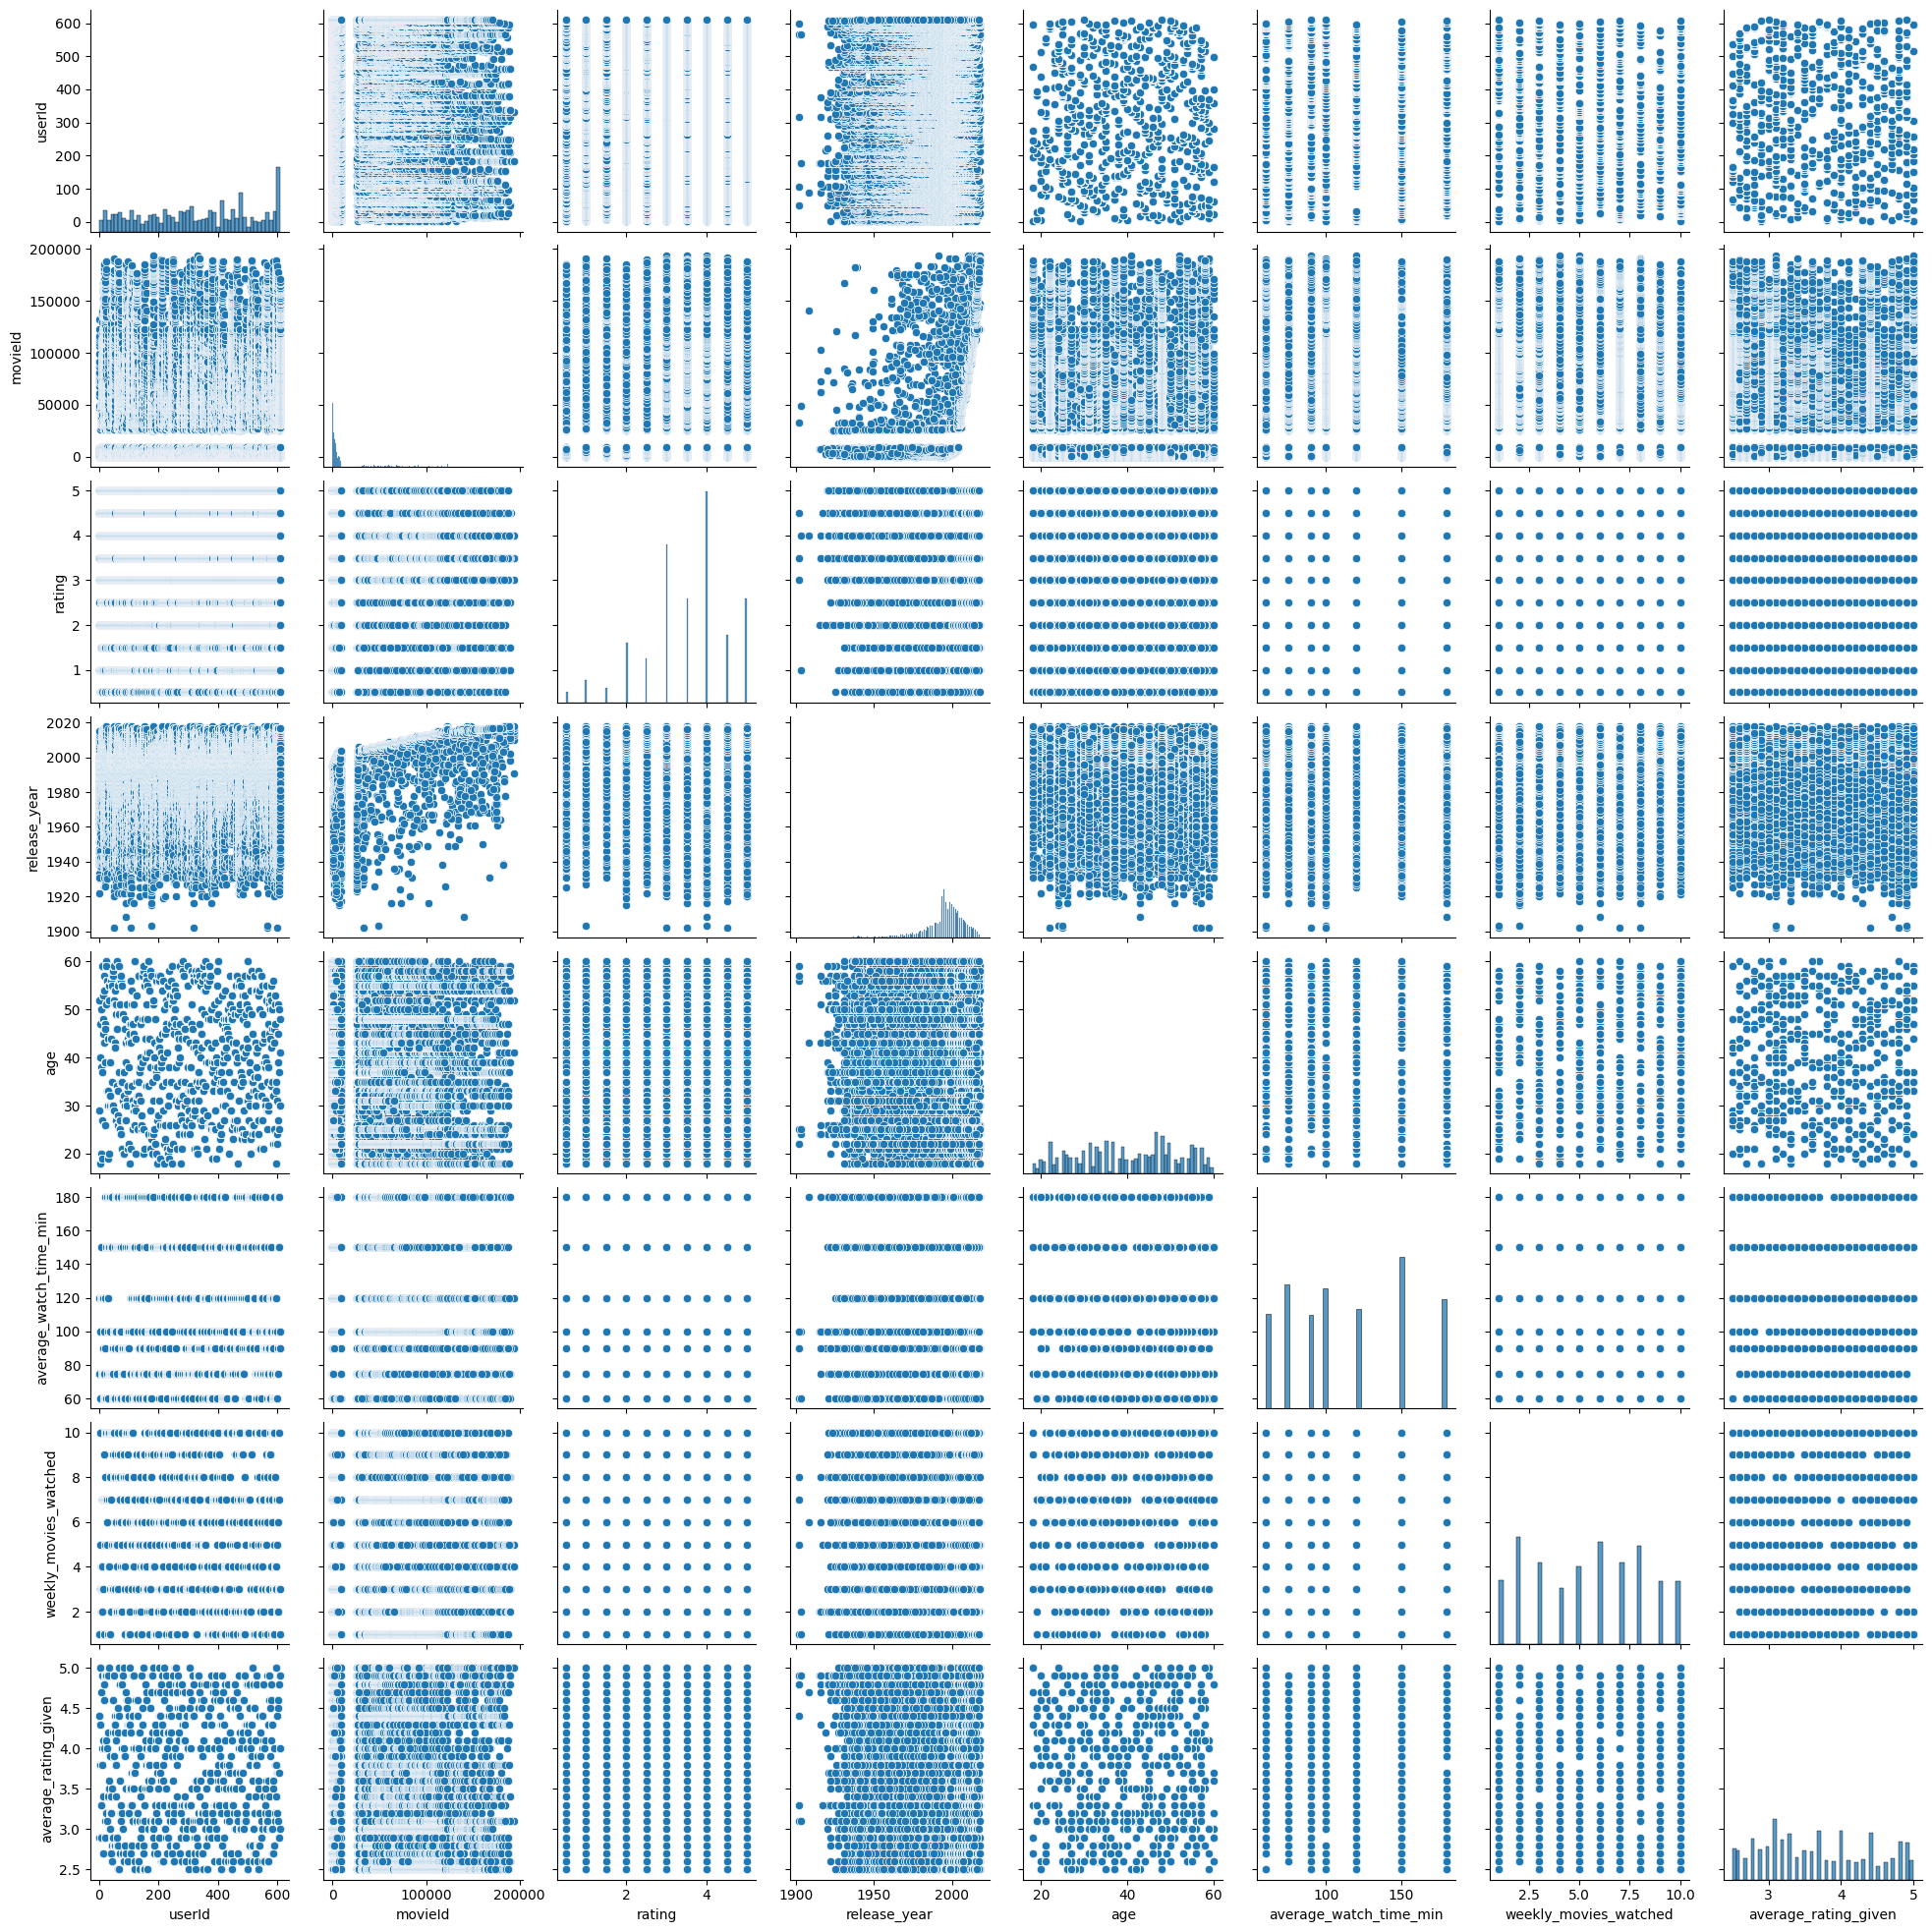

In [39]:
sns.pairplot(
    movie_data.select_dtypes(include=np.number)
)

plt.show()

Feature Engineering

In [40]:
movies["content"] = (
    movies["genres"].fillna("") + " " +
    movies["director"].fillna("") + " " +
    movies["actor"].fillna("") + " " +
    movies["language"].fillna("")
)

In [41]:
movies[["movieId", "title", "content"]].head()

,movieId,title,content
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy Ma...
1,2,Jumanji (1995),Adventure|Children|Fantasy Christopher Nolan N...
2,3,Grumpier Old Men (1995),"Comedy|Romance Quentin Tarantino Emma Stone, K..."
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance Steven Spielberg Emma Sto...
4,5,Father of the Bride Part II (1995),"Comedy Peter Jackson Jennifer Lawrence, Brad P..."


In [42]:
# Convert Text to Lowercase
movies["content"] = movies["content"].str.lower()

In [43]:
# Remove Extra Spaces
movies["content"] = movies["content"].str.replace(r"\s+", " ", regex=True)

In [44]:
#Check Unique Movies
movies["movieId"].nunique()

9742

In [45]:
# Create User–Movie Matrix= This matrix will be used for Collaborative Filtering.
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
user_movie_matrix = user_movie_matrix.fillna(0)

In [47]:
user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
user_movie_matrix.shape

(610, 9724)

# Content Based Fitering

In [49]:
# TF-IDF Vectorization - converts movie decriptions into numerical vectors
tfidf = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(
    movies["content"]
)

In [50]:
# Check TFIDF Matrix
print(tfidf_matrix.shape)

(9742, 65)


In [73]:
# Calculate Cosine Similarity
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)
print(cosine_sim.shape)

(9742, 9742)


In [74]:
movies["title"] = movies["title"].str.strip()

indices = pd.Series(
    data=movies.index,
    index=movies["title"]
).drop_duplicates()

In [75]:
indices.head()

title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
dtype: int64

In [76]:
# Content-Based Recommendation Function

def content_recommend(movie_title, cosine_sim=cosine_sim, top_n=10):

    # Remove extra spaces
    movie_title = movie_title.strip()

    # Search movie (case-insensitive)
    matched_movies = movies[
        movies["title"].str.contains(movie_title, case=False, na=False)
    ]

    # If movie not found
    if matched_movies.empty:
        return "Movie Not Found!"

    # Select the first matching movie
    selected_title = matched_movies.iloc[0]["title"]

    print(f"Selected Movie: {selected_title}")

    # Get movie index
    idx = indices[selected_title]

    # Calculate similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the movie itself
    similarity_scores = similarity_scores[1:top_n+1]

    # Get recommended movie indices
    movie_indices = [i[0] for i in similarity_scores]

    # Create recommendation DataFrame
    recommendations = movies.loc[
        movie_indices,
        ["movieId", "title", "genres", "actor", "director", "language", "release_year"]
    ].copy()

    # Add similarity score
    recommendations["Similarity Score"] = [
        round(score, 3) for _, score in similarity_scores
    ]

    # Reset index
    recommendations.reset_index(drop=True, inplace=True)

    return recommendations

In [77]:
content_recommend("Jumanji")

Selected Movie: Jumanji (1995)


,movieId,title,genres,actor,director,language,release_year,Similarity Score
0,92730,Rollo and the Woods Sprite (Rölli ja metsänhen...,Children|Fantasy,"Natalie Portman, Tom Hanks, Jennifer Lawrence",Christopher Nolan,English,2001,0.826
1,7247,Chitty Chitty Bang Bang (1968),Adventure|Children|Comedy|Fantasy|Musical,"Morgan Freeman, Jennifer Lawrence, Tom Hanks",Christopher Nolan,English,1968,0.789
2,2100,Splash (1984),Comedy|Fantasy|Romance,"Natalie Portman, Morgan Freeman, Jennifer Lawr...",Christopher Nolan,English,1984,0.788
3,3673,Benji the Hunted (1987),Adventure|Children,"Jennifer Lawrence, Robert Downey Jr., Morgan F...",Christopher Nolan,English,1987,0.780
4,173873,Gulliver's Travels (1996),Adventure|Children|Fantasy,"Tom Hanks, Natalie Portman, Keanu Reeves",Christopher Nolan,English,1996,0.777
5,27368,Asterix & Obelix: Mission Cleopatra (Astérix &...,Adventure|Comedy|Fantasy,"Tom Hanks, Jennifer Lawrence, Natalie Portman",Christopher Nolan,English,2002,0.776
6,56171,"Golden Compass, The (2007)",Adventure|Children|Fantasy,"Morgan Freeman, Tom Hanks, Keanu Reeves",Christopher Nolan,English,2007,0.775
7,107723,Highlander: The Search for Vengeance (2007),Action|Adventure|Fantasy,"Jennifer Lawrence, Emma Stone, Morgan Freeman",Christopher Nolan,English,2007,0.760
8,26696,Lionheart (1990),Action,"Morgan Freeman, Natalie Portman, Jennifer Lawr...",Christopher Nolan,English,1990,0.721
9,2366,King Kong (1933),Action|Adventure|Fantasy|Horror,"Morgan Freeman, Leonardo DiCaprio, Natalie Por...",Christopher Nolan,English,1933,0.713


In [81]:
content_recommend("King Kong")

Selected Movie: King Kong vs. Godzilla (Kingukongu tai Gojira) (1962)


,movieId,title,genres,actor,director,language,release_year,Similarity Score
0,4630,No Holds Barred (1989),Action,"Morgan Freeman, Brad Pitt, Scarlett Johansson",Quentin Tarantino,English,1989,0.855
1,122918,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,"Brad Pitt, Emma Stone, Morgan Freeman",Quentin Tarantino,English,2017,0.833
2,1690,Alien: Resurrection (1997),Action|Horror|Sci-Fi,"Morgan Freeman, Keanu Reeves, Brad Pitt",Quentin Tarantino,English,1997,0.826
3,338,Virtuosity (1995),Action|Sci-Fi|Thriller,"Scarlett Johansson, Brad Pitt, Robert Downey Jr.",Quentin Tarantino,English,1995,0.824
4,173291,Valerian and the City of a Thousand Planets (2...,Action|Adventure|Sci-Fi,"Robert Downey Jr., Morgan Freeman, Scarlett Jo...",Quentin Tarantino,English,2017,0.811
5,120466,Chappie (2015),Action|Thriller,"Scarlett Johansson, Morgan Freeman, Brad Pitt",Quentin Tarantino,English,2015,0.808
6,1127,"Abyss, The (1989)",Action|Adventure|Sci-Fi|Thriller,"Natalie Portman, Scarlett Johansson, Brad Pitt",Quentin Tarantino,English,1989,0.805
7,8361,"Day After Tomorrow, The (2004)",Action|Adventure|Drama|Sci-Fi|Thriller,"Brad Pitt, Morgan Freeman, Jennifer Lawrence",Quentin Tarantino,English,2004,0.790
8,114180,"Maze Runner, The (2014)",Action|Mystery|Sci-Fi,"Morgan Freeman, Scarlett Johansson, Robert Dow...",Quentin Tarantino,English,2014,0.789
9,1584,Contact (1997),Drama|Sci-Fi,"Scarlett Johansson, Robert Downey Jr., Brad Pitt",Quentin Tarantino,English,1997,0.789


# Collaborative Filtering (SVD)

In [82]:
# create the reader object
reader = Reader(rating_scale=(1,5))
reader = Reader(rating_scale=(0.5,5))

In [83]:
# Convert Data for Surprise
data = Dataset.load_from_df(

    ratings[
        ["userId","movieId","rating"]
    ],

    reader

)

In [84]:
# Train -Test split
trainset, testset = train_test_split(

    data,

    test_size=0.2,

    random_state=42

)

In [85]:
# Create the SVD Model
svd_model = SVD(

    n_factors=100,

    n_epochs=30,

    lr_all=0.005,

    reg_all=0.02,

    random_state=42

)

In [86]:
# Train the model
svd_model.fit(trainset)

In [87]:
# Predict the Ratings
predictions = svd_model.test(

    testset

)

In [88]:
# Evaluate Model
accuracy.rmse(predictions)
accuracy.mae(predictions)

RMSE: 0.8828
MAE:  0.6767


0.6766751153840092

In [89]:
# Predict the ratings for one movie
user_id = 100

movie_id = 25

prediction = svd_model.predict(

    user_id,

    movie_id

)

print(prediction.est)

3.5820969407952292


In [90]:
# recommendation function
def collaborative_recommend(
    user_id,
    ratings,
    movies,
    svd_model,
    top_n=10
):
    watched_movies = ratings[
        ratings["userId"] == user_id
    ]["movieId"].tolist()

    unseen_movies = movies[
        ~movies["movieId"].isin(watched_movies)
    ].copy()

    predictions = []

    for movie in unseen_movies["movieId"]:

        predicted_rating = svd_model.predict(
            user_id,
            movie
        ).est

        predictions.append(
            (movie, predicted_rating)
        )

    predictions = sorted(
        predictions,
        key=lambda x: x[1],
        reverse=True
    )

    top_predictions = predictions[:top_n]

    recommendation = pd.DataFrame(
        top_predictions,
        columns=["movieId","Predicted Rating"]
    )

    recommendation = recommendation.merge(
        movies,
        on="movieId"
    )

    return recommendation[
        ["movieId","title","Predicted Rating"]
    ]

In [91]:
collaborative_recommend(
    user_id=5,
    ratings=ratings,
    movies=movies,
    svd_model=svd_model,
    top_n=10
)

,movieId,title,Predicted Rating
0,1197,"Princess Bride, The (1987)",4.520292
1,1204,Lawrence of Arabia (1962),4.348454
2,1198,Raiders of the Lost Ark (Indiana Jones and the...,4.342157
3,1148,Wallace & Gromit: The Wrong Trousers (1993),4.321038
4,2067,Doctor Zhivago (1965),4.293950
5,720,Wallace & Gromit: The Best of Aardman Animatio...,4.291674
6,1223,"Grand Day Out with Wallace and Gromit, A (1989)",4.291308
7,2571,"Matrix, The (1999)",4.260213
8,1104,"Streetcar Named Desire, A (1951)",4.254697
9,3451,Guess Who's Coming to Dinner (1967),4.230311


# Hybrid Recommendation

In [92]:
def hybrid_recommend(
    user_id,
    favorite_movie,
    movies,
    ratings,
    svd_model,
    cosine_sim,
    indices,
    top_n=10,
    collaborative_weight=0.6,
    content_weight=0.4
):

    # Remove extra spaces
    favorite_movie = favorite_movie.strip()

    # Search for movie using partial title
    matched_movies = movies[
        movies["title"].str.contains(
            favorite_movie,
            case=False,
            na=False
        )
    ]

    # If no movie found
    if matched_movies.empty:
        return "Movie Not Found"

    # Use the first matching movie
    selected_title = matched_movies.iloc[0]["title"]

    print("Selected Movie:", selected_title)

    # Get movie index
    idx = indices[selected_title]

    # -----------------------------
    # Rest of your existing code
    # -----------------------------

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:]

    watched_movies = ratings[
        ratings["userId"] == user_id
    ]["movieId"].tolist()

    recommendations = []

    for movie_index, similarity in similarity_scores:

        movie_id = movies.iloc[movie_index]["movieId"]
        if movie_id == matched_movies.iloc[0]["movieId"]:
            continue

       # if movie_id in watched_movies:
        #    continue

        title = movies.iloc[movie_index]["title"]

        collaborative_score = svd_model.predict(
            user_id,
            movie_id
        ).est
        collaborative_score = (
            collaborative_score - 0.5
        ) / 4.5

        final_score = (
            collaborative_weight * collaborative_score
            +
            content_weight * similarity
        )

        recommendations.append([
            movie_id,
            title,
            round(similarity, 3),
            round(collaborative_score, 3),
            round(final_score, 3)
        ])

    recommendations = pd.DataFrame(
        recommendations,
        columns=[
            "movieId",
            "Title",
            "Content Score",
            "Collaborative Score",
            "Final Score"
        ]
    )

    recommendations = recommendations.sort_values(
        "Final Score",
        ascending=False
    )

    return recommendations.head(top_n)

In [93]:
hybrid_recommend(
    user_id=10,
    favorite_movie="Princess Bride",
    movies=movies,
    ratings=ratings,
    svd_model=svd_model,
    cosine_sim=cosine_sim,
    indices=indices
)

Selected Movie: Princess Bride, The (1987)


,movieId,Title,Content Score,Collaborative Score,Final Score
1,1604,Money Talks (1997),0.834,0.633,0.714
0,59103,"Forbidden Kingdom, The (2008)",0.854,0.613,0.710
152,3578,Gladiator (2000),0.586,0.785,0.706
9,27036,Merlin (1998),0.740,0.680,0.704
503,62,Mr. Holland's Opus (1995),0.490,0.847,0.704
301,736,Twister (1996),0.536,0.812,0.702
437,91529,"Dark Knight Rises, The (2012)",0.499,0.833,0.699
23,1251,8 1/2 (8½) (1963),0.707,0.693,0.698
7,4260,"Visit, The (2000)",0.742,0.668,0.697
262,122886,Star Wars: Episode VII - The Force Awakens (2015),0.548,0.793,0.695


In [96]:
# Create the 3 Hybrid Model
# Hybrid Model 1 (50-50)
hybrid_50 = hybrid_recommend(
    user_id=10,
    favorite_movie="Princess Bride",
    movies=movies,
    ratings=ratings,
    svd_model=svd_model,
    cosine_sim=cosine_sim,
    indices=indices,
    top_n=10,
    collaborative_weight=0.5,
    content_weight=0.5
)

# Hybrid Model 2 (60-40)
hybrid_60 = hybrid_recommend(
    user_id=10,
    favorite_movie="Princess Bride",
    movies=movies,
    ratings=ratings,
    svd_model=svd_model,
    cosine_sim=cosine_sim,
    indices=indices,
    top_n=10,
    collaborative_weight=0.6,
    content_weight=0.4
)

# Hybrid Model 3 (40-60)
hybrid_40 = hybrid_recommend(
    user_id=10,
    favorite_movie="Princess Bride",
    movies=movies,
    ratings=ratings,
    svd_model=svd_model,
    cosine_sim=cosine_sim,
    indices=indices,
    top_n=10,
    collaborative_weight=0.4,
    content_weight=0.6
)

Selected Movie: Princess Bride, The (1987)
Selected Movie: Princess Bride, The (1987)
Selected Movie: Princess Bride, The (1987)


In [97]:
# Compare the Three Models
comparison = pd.DataFrame({

    "Hybrid Model":[
        "Hybrid Model 1",
        "Hybrid Model 2",
        "Hybrid Model 3"
    ],

    "Collaborative Weight":[
        "50%",
        "60%",
        "40%"
    ],

    "Content Weight":[
        "50%",
        "40%",
        "60%"
    ],

    "Average Final Score":[
        round(hybrid_50["Final Score"].mean(),3),
        round(hybrid_60["Final Score"].mean(),3),
        round(hybrid_40["Final Score"].mean(),3)
    ]

})

comparison["Rank"] = comparison[
    "Average Final Score"
].rank(
    ascending=False,
    method="dense"
).astype(int)

comparison = comparison.sort_values(
    "Rank"
)

comparison

,Hybrid Model,Collaborative Weight,Content Weight,Average Final Score,Rank
2,Hybrid Model 3,40%,60%,0.712,1
1,Hybrid Model 2,60%,40%,0.703,2
0,Hybrid Model 1,50%,50%,0.702,3


In [98]:
# Best Hybrid Model
best_model = comparison.iloc[0]

print("="*60)
print("BEST HYBRID MODEL")
print("="*60)

print("Model :", best_model["Hybrid Model"])
print("Collaborative Weight :", best_model["Collaborative Weight"])
print("Content Weight :", best_model["Content Weight"])
print("Average Final Score :", best_model["Average Final Score"])

BEST HYBRID MODEL
Model : Hybrid Model 3
Collaborative Weight : 40%
Content Weight : 60%
Average Final Score : 0.712


# Model Evaluation 

In [99]:
from surprise import accuracy

# Predict ratings on the test set
predictions = svd_model.test(testset)

# RMSE
rmse = accuracy.rmse(predictions, verbose=False)

# MAE
mae = accuracy.mae(predictions, verbose=False)

print("RMSE :", round(rmse,3))
print("MAE  :", round(mae,3))

RMSE : 0.883
MAE  : 0.677


In [101]:
def precision_at_k(recommendations, ratings, user_id, k=10, threshold=3.5):

    # Top-K recommended movies
    recommended = recommendations.head(k)["movieId"].tolist()

    # Movies rated >= threshold by the user
    relevant = ratings[
        (ratings["userId"] == user_id) &
        (ratings["rating"] >= threshold)
    ]["movieId"].tolist()

    hits = len(set(recommended).intersection(set(relevant)))

    precision = hits / k

    return precision

In [102]:
def recall_at_k(recommendations, ratings, user_id, k=10, threshold=3.5):

    recommended = recommendations.head(k)["movieId"].tolist()

    relevant = ratings[
        (ratings["userId"] == user_id) &
        (ratings["rating"] >= threshold)
    ]["movieId"].tolist()

    hits = len(set(recommended).intersection(set(relevant)))

    if len(relevant) == 0:
        return 0

    recall = hits / len(relevant)

    return recall

In [103]:
user_id = 10

precision = precision_at_k(
    recommendations=hybrid_40,
    ratings=ratings,
    user_id=user_id,
    k=10
)

recall = recall_at_k(
    recommendations=hybrid_40,
    ratings=ratings,
    user_id=user_id,
    k=10
)

print("Precision@10 :", round(precision,3))
print("Recall@10    :", round(recall,3))

Precision@10 : 0.0
Recall@10    : 0.0


In [104]:
evaluation = pd.DataFrame({

    "Model": ["Hybrid Model 3 (40-60)"],

    "RMSE": [round(rmse,3)],

    "MAE": [round(mae,3)],

    "Precision@10": [round(precision,3)],

    "Recall@10": [round(recall,3)]

})

evaluation

,Model,RMSE,MAE,Precision@10,Recall@10
0,Hybrid Model 3 (40-60),0.883,0.677,0.0,0.0


In [105]:
recommended = hybrid_40["movieId"].tolist()

relevant = ratings[
    (ratings["userId"] == 5) &
    (ratings["rating"] >= 4)
]["movieId"].tolist()

print("Recommended:", recommended)
print("Relevant:", relevant)

print("Common Movies:",
      set(recommended).intersection(set(relevant)))

Recommended: [59103, 1604, 27036, 4260, 76293, 7036, 1251, 4003, 80864, 86864]
Relevant: [1, 21, 34, 36, 50, 58, 110, 232, 247, 261, 290, 296, 367, 457, 474, 475, 527, 531, 588, 590, 594, 595, 596]
Common Movies: set()
